## **LangGraph Persistence Layer**

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
import os


In [4]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [5]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanations: str

## **Define the node**

In [14]:
def generate_joke(state: JokeState):
    topic = state["topic"]

    prompt = f"Generate the joke based on the topics {topic}. joke must be small and punchy."
    joke = llm.invoke(prompt).content

    return {
        'joke': joke
    }


def explanation_joke(state: JokeState):
    prompt = f"Explain this joke very professional way. if its not good say its bad joke. the joke is: {state["joke"]}"
    response = llm.invoke(prompt).content

    return {
        "explanations": response
    }

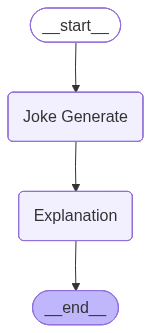

In [15]:
from langgraph.checkpoint.memory import InMemorySaver
graph = StateGraph(JokeState)

graph.add_node("Joke Generate", generate_joke)
graph.add_node("Explanation", explanation_joke)

graph.add_edge(START, "Joke Generate")
graph.add_edge("Joke Generate", "Explanation")
graph.add_edge("Explanation", END)

workflow = graph.compile(checkpointer=InMemorySaver())

workflow



In [16]:
config = {
    "configurable": {
        "thread_id": "chat_1"
    }
}

response = workflow.invoke(
    {
        "topic": "Corporate Office."
    },
    config=config
)

In [18]:
response

{'topic': 'Corporate Office.',
 'joke': 'Why did the scarecrow become the CEO of the corporate office? \n\nBecause he was outstanding in his field!',
 'explanations': 'This joke employs a clever play on words, primarily relying on a pun that juxtaposes two different meanings of the phrase "outstanding in his field." \n\n1. **Contextual Analysis**: The setup introduces a scarecrow, a figure traditionally associated with agriculture and rural settings, and then fantastically positions it within the corporate hierarchy as a Chief Executive Officer (CEO). This juxtaposition itself creates an absurd scenario that captures attention.\n\n2. **Wordplay and Double Meaning**: The humor hinges on the double entendre of "outstanding." In a literal sense, "outstanding" can mean standing out prominently, as in the scarecrow being physically situated in a field (designed to deter birds from crops). In a figurative context, "outstanding" is often used to denote someone exceptional or highly competent 

## **Get the state value**

In [19]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'Corporate Office.', 'joke': 'Why did the scarecrow become the CEO of the corporate office? \n\nBecause he was outstanding in his field!', 'explanations': 'This joke employs a clever play on words, primarily relying on a pun that juxtaposes two different meanings of the phrase "outstanding in his field." \n\n1. **Contextual Analysis**: The setup introduces a scarecrow, a figure traditionally associated with agriculture and rural settings, and then fantastically positions it within the corporate hierarchy as a Chief Executive Officer (CEO). This juxtaposition itself creates an absurd scenario that captures attention.\n\n2. **Wordplay and Double Meaning**: The humor hinges on the double entendre of "outstanding." In a literal sense, "outstanding" can mean standing out prominently, as in the scarecrow being physically situated in a field (designed to deter birds from crops). In a figurative context, "outstanding" is often used to denote someone exceptional o

## **Get all history of this chat**

In [22]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'topic': 'Corporate Office.', 'joke': 'Why did the scarecrow become the CEO of the corporate office? \n\nBecause he was outstanding in his field!', 'explanations': 'This joke employs a clever play on words, primarily relying on a pun that juxtaposes two different meanings of the phrase "outstanding in his field." \n\n1. **Contextual Analysis**: The setup introduces a scarecrow, a figure traditionally associated with agriculture and rural settings, and then fantastically positions it within the corporate hierarchy as a Chief Executive Officer (CEO). This juxtaposition itself creates an absurd scenario that captures attention.\n\n2. **Wordplay and Double Meaning**: The humor hinges on the double entendre of "outstanding." In a literal sense, "outstanding" can mean standing out prominently, as in the scarecrow being physically situated in a field (designed to deter birds from crops). In a figurative context, "outstanding" is often used to denote someone exceptional 

## **Chat 2**

In [24]:
topic = "Corporate Boss"
config = {
    "configurable": {
        "thread_id": "chat_2"
    }
}

response = workflow.invoke(
    {
        "topic": topic
    },
    config=config
)

In [25]:
response

{'topic': 'Corporate Boss',
 'joke': 'Why did the corporate boss bring a ladder to the meeting?  \n\nBecause they wanted to take their leadership skills to the next level!',
 'explanations': 'This joke employs a play on words and a pun to create humor, utilizing the dual meaning of "taking skills to the next level." In a corporate context, "leadership skills" often refer to an individual\'s ability to guide and inspire others, while "taking to the next level" suggests improving or enhancing these skills.\n\nThe humor arises from the absurdity of the corporate boss literally bringing a ladder to a meeting—an action that is incongruous with the typically abstract nature of professional development discussions. The juxtaposition of a physical ladder, which is a tool for ascending in a literal sense, with the metaphorical concept of advancing one’s abilities creates a comedic effect.\n\nHowever, it should be noted that while the joke employs clever wordplay, its effectiveness may be limite

In [26]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'Corporate Boss', 'joke': 'Why did the corporate boss bring a ladder to the meeting?  \n\nBecause they wanted to take their leadership skills to the next level!', 'explanations': 'This joke employs a play on words and a pun to create humor, utilizing the dual meaning of "taking skills to the next level." In a corporate context, "leadership skills" often refer to an individual\'s ability to guide and inspire others, while "taking to the next level" suggests improving or enhancing these skills.\n\nThe humor arises from the absurdity of the corporate boss literally bringing a ladder to a meeting—an action that is incongruous with the typically abstract nature of professional development discussions. The juxtaposition of a physical ladder, which is a tool for ascending in a literal sense, with the metaphorical concept of advancing one’s abilities creates a comedic effect.\n\nHowever, it should be noted that while the joke employs clever wordplay, its effectiv

In [27]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'Corporate Boss', 'joke': 'Why did the corporate boss bring a ladder to the meeting?  \n\nBecause they wanted to take their leadership skills to the next level!', 'explanations': 'This joke employs a play on words and a pun to create humor, utilizing the dual meaning of "taking skills to the next level." In a corporate context, "leadership skills" often refer to an individual\'s ability to guide and inspire others, while "taking to the next level" suggests improving or enhancing these skills.\n\nThe humor arises from the absurdity of the corporate boss literally bringing a ladder to a meeting—an action that is incongruous with the typically abstract nature of professional development discussions. The juxtaposition of a physical ladder, which is a tool for ascending in a literal sense, with the metaphorical concept of advancing one’s abilities creates a comedic effect.\n\nHowever, it should be noted that while the joke employs clever wordplay, its effecti